In [1]:
import os

os.environ['KAGGLE_USERNAME'] = 'aliaanasserr'
os.environ['KAGGLE_KEY']      = "020ecbcf7e9cc7c7c24badefb3a21346"

import kaggle
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'msambare/fer2013',
    path='./data',
    unzip=True
)

print('Dataset downloaded')

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
Dataset downloaded


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


Classes: ['sad', 'surprise', 'neutral', 'disgust', 'fear', 'angry', 'happy']
Number of classes: 7

Image counts:
  sad: 4830 images
  surprise: 3171 images
  neutral: 4965 images
  disgust: 436 images
  fear: 4097 images
  angry: 3995 images
  happy: 7215 images


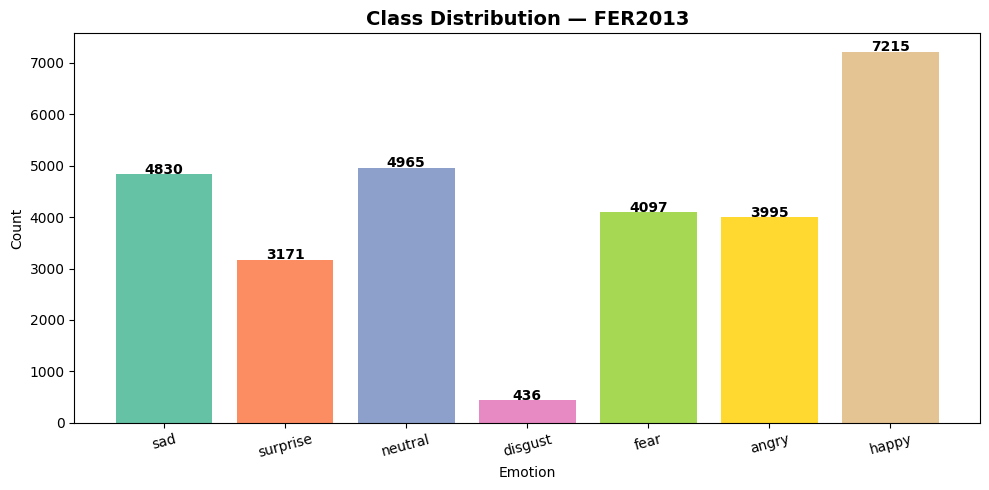

In [3]:
TRAIN_DIR = './data/train'
TEST_DIR  = './data/test'

classes = os.listdir(TRAIN_DIR)
print(f'Classes: {classes}')
print(f'Number of classes: {len(classes)}')

print('\nImage counts:')
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f'  {cls}: {count} images')

counts = [len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes]

plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color=plt.cm.Set2.colors)
plt.title('Class Distribution — FER2013', fontsize=14, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=15)
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Test,rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f'Train samples: {train_generator.samples}')
print(f'Test samples:  {test_generator.samples}')
print(f'Classes: {class_names}')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Train samples: 28709
Test samples:  7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
def build_model(base_model, num_classes, model_name):
    base_model.trainable = False

    # adding layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f'{model_name} built')
    return model


vgg_base     = VGG16(weights='imagenet',     include_top=False, input_shape=(224, 224, 3))
resnet_base  = ResNet50(weights='imagenet',  include_top=False, input_shape=(224, 224, 3))
mobile_base  = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg_model    = build_model(vgg_base,    num_classes, 'VGG16')
resnet_model = build_model(resnet_base, num_classes, 'ResNet50')
mobile_model = build_model(mobile_base, num_classes, 'MobileNetV2')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 built
ResNet50 built
MobileNetV2 built


In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

histories = {}

for name, model in [('VGG16', vgg_model), ('ResNet50', resnet_model), ('MobileNetV2', mobile_model)]:
    print(f'Training {name}...')

    checkpoint = ModelCheckpoint(
        f'{name}_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    )

    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=15,
        callbacks=callbacks + [checkpoint]
    )

    histories[name] = history
    print(f'{name} training complete')

Training VGG16...
Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.2786 - loss: 1.8123
Epoch 1: val_accuracy improved from None to 0.34244, saving model to VGG16_best.keras

Epoch 1: finished saving model to VGG16_best.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 456s 486ms/step - accuracy: 0.3107 - loss: 1.7317 - val_accuracy: 0.3424 - val_loss: 1.6324 - learning_rate: 0.0010
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.3519 - loss: 1.6500
Epoch 2: val_accuracy improved from 0.34244 to 0.35525, saving model to VGG16_best.keras

Epoch 2: finished saving model to VGG16_best.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 422s 470ms/step - accuracy: 0.3540 - loss: 1.6417 - val_accuracy: 0.3553 - val_loss: 1.5972 - learning_rate: 0.0010
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.3708 - loss: 1.6200
Epoch 3: val_accuracy improved from 0.35525 to 0.39579, saving model to VGG16_best.keras

Epoch 3: finished saving model to VGG16_best.keras
898/898 

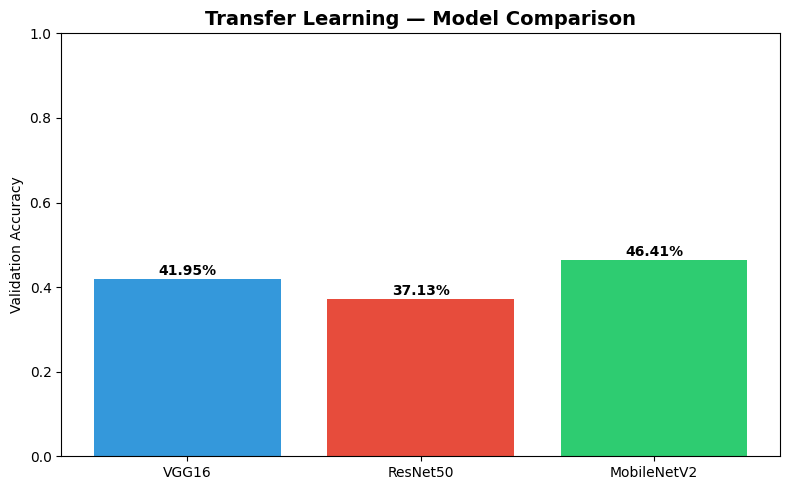

In [7]:
models_names = ['VGG16', 'ResNet50', 'MobileNetV2']
accuracies   = [0.4195,   0.3713,    0.4641]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, accuracies,
               color=['#3498db', '#e74c3c', '#2ecc71'])
plt.ylim(0, 1)
plt.title('Transfer Learning — Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [8]:
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print('Class names saved')
print(class_names)

Class names saved
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [11]:
from google.colab import files

files.download('VGG16_best.keras')
files.download('ResNet50_best.keras')
files.download('MobileNetV2_best.keras')
files.download('class_names.json')
files.download('model_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>